# A1-1. 쇼핑몰 고객 분석과 RFM 세분화

H&M 온라인·오프라인 거래 샘플로 **누가 자주 오고 많이 사는지** 분석해 단골을 찾는 리포트입니다.
전처리와 분석 로직은 `src/pipeline.py`의 `DataAnalyzer` 클래스에 있고, 이 노트북은 그 메서드를 순서대로 호출하며 결과를 해석합니다.

## 데이터 개요
| 항목 | 값 |
|---|---|
| 출처 | Kaggle 대회 *H&M Personalized Fashion Recommendations* (거래, 상품, 고객 테이블) |
| 샘플링 | 전체 고객 중 5,000명 무작위 추출 (`seed=42`), 거래가 없는 고객 제외 |
| 규모 | 거래 **113,723행**, 고객 **4,962명**, 상품 34,543개, 컬럼 41개 |
| 기간 | 2018-09-20 ~ 2020-09-22 |
| 이미지 | 인기 상품 **765장** (이미지가 있는 거래는 전체의 16.7%) |
| 데이터 유형 | 수치(`price`, `age`), 범주(`product_group_name` 등), 날짜(`t_dat`), 텍스트(`prod_name`), 이미지 배열 |

## 읽기 전에 알아둘 점
- **`price`는 정규화된 상대 금액**입니다 (중앙값 약 0.025). 읽기 쉽도록 1,000을 곱한 `amount`(금액 지수)를 분석에 사용하며, 실제 통화 금액이 아닙니다.
- 수량 컬럼이 없어서 거래 한 행은 한 개 구매이며 `amount = price × 1000`입니다.
- **이미지는 765장만 확보**했습니다 (Kaggle API 요청 제한으로 목표 1,000장 중 일부만 받음). 이미지 피처는 이 상품들에만 실제 값이 있고, 나머지는 그룹 평균으로 대치했습니다. 이 한계는 3장과 9장에서 다시 다룹니다.
- 허용된 라이브러리(NumPy, Pandas, Matplotlib, Seaborn)만 사용했습니다.

In [1]:
import platform
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.pipeline import DataAnalyzer  # noqa: E402

# 한글 폰트
plt.rcParams["font.family"] = {"Darwin": "AppleGothic", "Windows": "Malgun Gothic"}.get(
    platform.system(), "NanumGothic"
)
plt.rcParams["axes.unicode_minus"] = False

# 색: 범주는 막대 라벨로 구분하므로 단일 파랑, 크기는 파랑 순차색, 상관은 파랑-회색-빨강 발산색
BLUE = "#2a78d6"
SEQ = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#184f95", "#0d366b"]
)
DIV = LinearSegmentedColormap.from_list("div_blue_red", ["#2a78d6", "#f0efec", "#e34948"])
plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.grid.axis": "y",
        "grid.alpha": 0.25,
        "figure.dpi": 110,
    }
)


def label(ax, title, xlabel, ylabel):
    ax.set_title(title, loc="left", fontsize=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

## 1. 데이터 로드와 기본 탐색

In [2]:
analyzer = DataAnalyzer()
df = analyzer.load_data()
print(df.shape)
df.head()

(113723, 36)


,t_dat,customer_id,article_id,price,sales_channel_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,...,garment_group_no,garment_group_name,detail_desc,FN,Active,club_member_status,fashion_news_frequency,age,postal_code,amount
0,2018-09-20,06a2e63d0363dcbd83c0e4f800727805f2881f53b4f024...,0516000070,0.016932,1,516000,Agnes LS R-neck,255,T-shirt,Garment Upper body,...,1005,Jersey Fancy,Fitted top in stretch jersey with a round neck...,NaN,NaN,ACTIVE,NONE,44.0,e641b058c50725e5426fef2c1ad6fa218fe1010f360992...,16.932203
1,2018-09-20,06a2e63d0363dcbd83c0e4f800727805f2881f53b4f024...,0661794001,0.152525,1,661794,Flamingo,263,Coat,Garment Upper body,...,1007,Outdoor,Short coat in a woven wool blend with a high s...,NaN,NaN,ACTIVE,NONE,44.0,e641b058c50725e5426fef2c1ad6fa218fe1010f360992...,152.525424
2,2018-09-20,0eafd19d6a3b703d109aff9ec5932624ab008d4a87bcc3...,0496111007,0.033881,2,496111,Devon basic sweater,252,Sweater,Garment Upper body,...,1003,Knitwear,Jumper in a soft knit with visible seams at th...,NaN,NaN,ACTIVE,NONE,22.0,d62642379558040b8dcbe5ee161ec6b9ce4984e49b6ea3...,33.881356
3,2018-09-20,0eafd19d6a3b703d109aff9ec5932624ab008d4a87bcc3...,0651273001,0.022017,2,651273,PINE JERSEY BLOUSE,252,Sweater,Garment Upper body,...,1005,Jersey Fancy,Long-sleeved blouse in soft slub cotton jersey...,NaN,NaN,ACTIVE,NONE,22.0,d62642379558040b8dcbe5ee161ec6b9ce4984e49b6ea3...,22.016949
4,2018-09-20,0eafd19d6a3b703d109aff9ec5932624ab008d4a87bcc3...,0613826004,0.042356,2,613826,Loris denim TW,262,Jacket,Garment Upper body,...,1007,Outdoor,"Jacket in washed denim with a collar, buttons ...",NaN,NaN,ACTIVE,NONE,22.0,d62642379558040b8dcbe5ee161ec6b9ce4984e49b6ea3...,42.355932


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 113723 entries, 0 to 113722
Data columns (total 36 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   t_dat                         113723 non-null  datetime64[us]
 1   customer_id                   113723 non-null  str           
 2   article_id                    113723 non-null  str           
 3   price                         113723 non-null  float64       
 4   sales_channel_id              113723 non-null  int64         
 5   product_code                  113723 non-null  int64         
 6   prod_name                     113723 non-null  str           
 7   product_type_no               113723 non-null  int64         
 8   product_type_name             113723 non-null  str           
 9   product_group_name            113723 non-null  str           
 10  graphical_appearance_no       113723 non-null  int64         
 11  graphical_appearance_nam

In [4]:
df[["price", "amount", "age"]].describe().round(3)

,price,amount,age
count,113723.000,113723.000,113269.000
mean,0.028,27.689,35.550
std,0.019,18.840,12.721
min,0.000,0.424,16.000
25%,0.016,15.576,25.000
50%,0.025,25.407,31.000
75%,0.034,33.881,46.000
max,0.493,493.220,87.000


**해석**
- 거래 113,723행, 컬럼 41개로 미션 최소 기준(1,000건, 8컬럼)을 크게 넘습니다. 날짜(`t_dat`), 수치, 범주, 텍스트 컬럼이 이미 섞여 있고 이미지 배열은 2장에서 추가합니다.
- `info()`상 결측은 고객 정보(`age` 454건)와 상품 설명(`detail_desc` 395건) 정도로 적습니다. `FN`, `Active`는 절반 이상이 비어 있지만 이번 분석에는 쓰지 않습니다.
- `amount`의 평균은 27.7, 중앙값은 25.4이고 최댓값은 493.2입니다. 평균이 중앙값보다 크고 최댓값이 매우 커서 **오른쪽으로 긴 꼬리를 가진 분포**입니다. 따라서 4장에서 이상치를 점검하고, 대표값은 평균보다 중앙값을 함께 봐야 합니다.

## 2. 피처 엔지니어링 (텍스트, 이미지)

- **텍스트**: 상품명(`prod_name`)의 단어 수와 문자 수를 파생 변수로 추가합니다.
- **이미지**: `(N, 높이, 너비, 채널)` 배열에서 이미지별 평균과 표준편차를 **반복문 없이** `axis=(1, 2, 3)` 집계로 한 번에 계산합니다.
  - 원본(1750×1166)을 중앙에서 자르고 `arr[::10, ::10]`로 다운샘플링해 `(175, 116, 3)`으로 저장해 두었습니다 (`src/build_image_array.py`).
  - 평균은 전반적인 밝기, 표준편차는 명암 대비로 해석합니다.

In [5]:
analyzer.add_text_features("prod_name")
df = analyzer.df
df[["prod_name", "prod_name_word_count", "prod_name_len"]].drop_duplicates("prod_name").head()

,prod_name,prod_name_word_count,prod_name_len
0,Agnes LS R-neck,3,15
1,Flamingo,1,8
2,Devon basic sweater,3,19
3,PINE JERSEY BLOUSE,3,18
4,Loris denim TW,3,14


이미지 배열: (765, 175, 116, 3) uint8


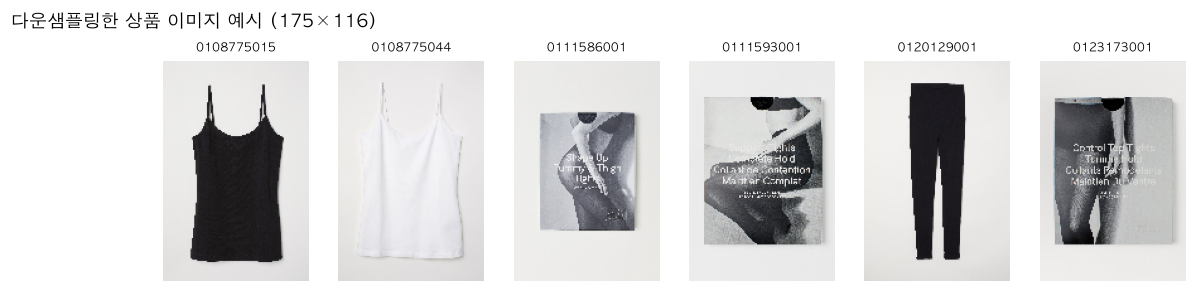

벡터화 결과: 158.3974 / 직접 계산: 158.3974


,article_id,img_mean,img_std
1,0661794001,216.009589,25.177439
5,0688873001,133.798933,97.414253
9,0565379001,142.074729,99.877082
31,0502224001,200.508785,68.666738
33,0536139010,216.355304,23.807251


In [6]:
images, article_ids = analyzer.load_image_arrays()
print("이미지 배열:", images.shape, images.dtype)

fig, axes = plt.subplots(1, 6, figsize=(12, 3))
for ax, img, aid in zip(axes, images[:6], article_ids[:6]):
    ax.imshow(img)
    ax.set_title(aid, fontsize=8)
    ax.axis("off")
fig.suptitle("다운샘플링한 상품 이미지 예시 (175×116)", fontsize=12, x=0.01, ha="left")
plt.show()

df = analyzer.add_image_features(images, article_ids)
# 검증: 첫 번째 이미지의 평균을 직접 계산한 값과 같은지 확인
first = df[df["article_id"] == article_ids[0]].iloc[0]
print("벡터화 결과:", round(first["img_mean"], 4), "/ 직접 계산:", round(images[0].mean(), 4))
df[df["has_image"]][["article_id", "img_mean", "img_std"]].drop_duplicates("article_id").head()

**해석**
- 이미지가 있는 상품은 765개이고, 이 상품들이 전체 거래의 16.7%(18,952행)를 차지합니다. 나머지 83.3%는 이미지 피처가 결측입니다.
- 상품명은 평균 2.73단어(중앙값 3, 최대 8)로 짧아서, 단어 수는 상품명 길이를 거칠게 구분하는 정도의 정보만 줍니다.
- 이미지 평균 밝기는 평균 184.2(255 만점)이고 표준편차는 30.9입니다. 대부분 흰 배경 위에 상품을 놓은 사진이라 밝기 값이 배경에 크게 좌우됩니다. 따라서 이 피처는 상품 스타일보다 **배경 대비 옷의 어두운 정도**를 반영한다고 해석해야 합니다.

## 3. 결측치 처리

In [7]:
analyzer.missing_report().round(2)

,missing,missing_pct
img_mean,94771,83.33
img_std,94771,83.33
Active,64726,56.92
FN,64185,56.44
fashion_news_frequency,531,0.47
age,454,0.40
detail_desc,395,0.35
club_member_status,357,0.31


대치 방침은 다음과 같습니다.
- `age`: 고객 단위로 `club_member_status` 그룹의 중앙값으로 채움 (`unit_col="customer_id"`로 고객당 한 번만 집계)
- `img_mean`, `img_std`: 상품 단위로 `product_group_name` 그룹의 평균으로 채움 (`unit_col="article_id"`). 거래가 많은 인기 상품에 평균이 쏠리지 않도록 상품당 한 번만 집계합니다.
- 이미지 값이 실제로 있었는지는 `has_image` 컬럼으로 남겨 둡니다.

In [8]:
before = analyzer.df[["age", "img_mean", "img_std"]].isna().sum()
raw_img_mean = analyzer.df["img_mean"].copy()

analyzer.handle_missing_values("age", "group_median", "club_member_status", unit_col="customer_id")
analyzer.handle_missing_values("img_mean", "group_mean", "product_group_name", unit_col="article_id")
analyzer.handle_missing_values("img_std", "group_mean", "product_group_name", unit_col="article_id")
df = analyzer.df

after = df[["age", "img_mean", "img_std"]].isna().sum()
display(pd.DataFrame({"대치 전 결측": before, "대치 후 결측": after}))

# 이미지가 실제로 있던 행의 값은 바뀌지 않았는지 확인
has = df["has_image"]
print("실제 이미지 값 보존:", bool((df.loc[has, "img_mean"] == raw_img_mean[has]).all()))

,대치 전 결측,대치 후 결측
age,454,0
img_mean,94771,0
img_std,94771,0


실제 이미지 값 보존: True


**해석**
- `age`는 454건(0.40%)으로 극히 적어 그룹 중앙값 대치의 영향이 거의 없습니다.
- 이미지 피처는 94,771행(83.3%)이 결측이라 대치된 값이 대부분입니다. 그룹 평균은 해당 상품군의 평균적인 사진을 가정한 값이므로 개별 상품의 정보를 담지 못합니다.
- 따라서 **이미지 피처를 쓰는 분석은 `has_image=True`인 행으로 한정**하고(5, 6장), 대치된 값은 모델 입력용 채움값으로만 봅니다. 또 이미지가 있는 상품은 판매량 상위 상품이라 전체 상품을 대표하지 않습니다.

## 4. 이상치 탐지와 처리 (IQR)

`DataAnalyzer.iqr_bounds`와 `detect_outliers`가 IQR 규칙을 직접 구현한 메서드입니다.

- 하한 = Q1 − 1.5 × IQR, 상한 = Q3 + 1.5 × IQR
- 범위를 벗어난 값을 이상치로 보고, `treat_outliers(method="clip")`로 상·하한 값에 맞춰 행 수를 유지한 채 처리합니다.

In [9]:
lower, upper = analyzer.iqr_bounds("amount", threshold=1.5)
outliers = analyzer.detect_outliers("amount", threshold=1.5)
treated = analyzer.treat_outliers("amount", threshold=1.5, method="clip")

print(f"정상 범위: {lower:.2f} ~ {upper:.2f}")
print(f"이상치: {len(outliers):,}건 ({len(outliers) / len(df):.1%}), 매출 비중 {outliers['amount'].sum() / df['amount'].sum():.1%}")
print()
print("이상치가 많은 상품군")
display(outliers["product_group_name"].value_counts().head(5).rename("건수").to_frame())

compare = pd.DataFrame(
    {"처리 전": df["amount"].describe(), "처리 후(클리핑)": treated["amount"].describe()}
).round(2)
compare

정상 범위: -11.88 ~ 61.34
이상치: 5,144건 (4.5%), 매출 비중 13.9%

이상치가 많은 상품군


,건수
product_group_name,
Garment Upper body,2487
Garment Lower body,1170
Garment Full body,1051
Shoes,343
Accessories,40


,처리 전,처리 후(클리핑)
count,113723.00,113723.00
mean,27.69,26.62
std,18.84,14.73
min,0.42,0.42
25%,15.58,15.58
50%,25.41,25.41
75%,33.88,33.88
max,493.22,61.34


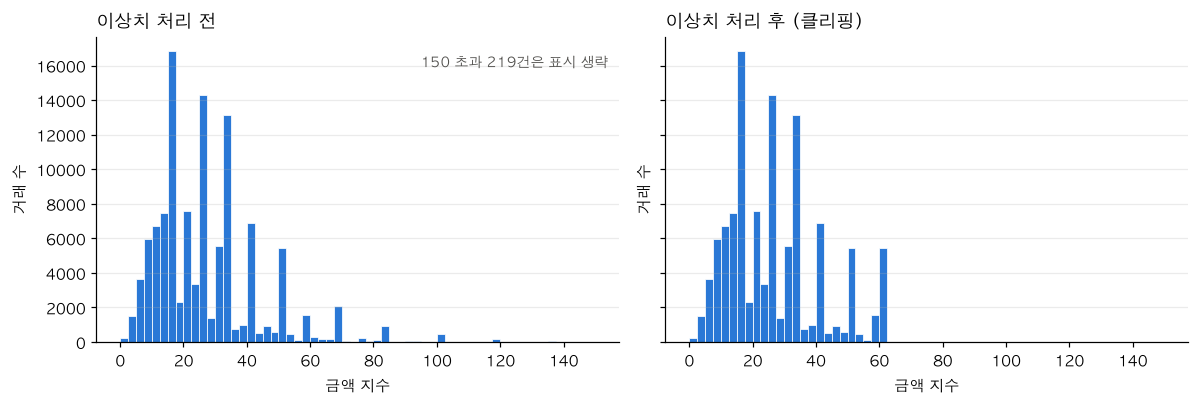

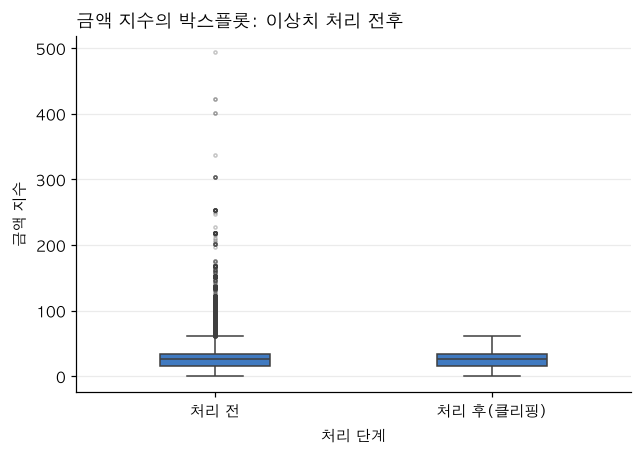

In [10]:
before, after = df["amount"], treated["amount"]
edges = np.linspace(0, 150, 61)  # 가독성을 위해 150까지만 표시

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, s, title in zip(axes, [before, after], ["이상치 처리 전", "이상치 처리 후 (클리핑)"]):
    ax.hist(s, bins=edges, color=BLUE, edgecolor="white", linewidth=0.5)
    label(ax, title, "금액 지수", "거래 수")
axes[0].text(0.98, 0.9, f"150 초과 {int((before > 150).sum()):,}건은 표시 생략", transform=axes[0].transAxes,
             ha="right", fontsize=9, color="#52514e")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 4.2))
sns.boxplot(
    data=pd.DataFrame({"처리 전": before, "처리 후(클리핑)": after}),
    ax=ax, color=BLUE, width=0.4, fliersize=2, flierprops={"alpha": 0.3},
)
label(ax, "금액 지수의 박스플롯: 이상치 처리 전후", "처리 단계", "금액 지수")
plt.show()

**해석**
- 정상 범위는 -11.9 ~ 61.3이고 하한은 음수라 **상한을 넘는 5,144건(4.5%)만 이상치**입니다. 매출 기준으로는 13.9%를 차지합니다.
- 이상치는 `Jacket`, `Trousers`, `Dress` 등 상대적으로 비싼 상품 유형에 몰려 있어 입력 오류가 아니라 **정상적인 고가 상품 구매**입니다.
- 클리핑하면 표준편차가 18.8에서 14.7로 21.8% 줄고 평균은 27.7에서 26.6로 낮아지지만, 중앙값(25.4)은 그대로입니다.
- 시사점: 분포 분석(히스토그램, 상관)에서는 클리핑한 값을 쓰는 편이 안정적이지만, **RFM의 Monetary는 원본 금액을 써야** 합니다. 고가 상품을 많이 산 고객이 곧 높은 가치의 고객이기 때문입니다.

## 5. 통계 분석

In [11]:
img_analyzer = DataAnalyzer()
img_analyzer.df = df[df["has_image"]]  # 이미지가 실제로 있는 행만

basic = analyzer.summary_statistics(["amount", "age", "prod_name_word_count"])
image = img_analyzer.summary_statistics(["img_mean", "img_std"])
pd.concat([basic, image]).round(2)

,count,mean,median,std,min,q1,q3,max,iqr
amount,113723.0,27.69,25.41,18.84,0.42,15.58,33.88,493.22,18.31
age,113723.0,35.54,31.00,12.70,16.00,25.00,46.00,87.00,21.00
prod_name_word_count,113723.0,2.73,3.00,1.13,1.00,2.00,3.00,8.00,1.00
img_mean,18952.0,184.19,184.68,30.89,44.96,165.26,205.69,235.64,40.44
img_std,18952.0,68.27,76.70,29.55,2.66,54.07,92.26,116.38,38.20


In [12]:
pairs_img = [("amount", "img_mean"), ("amount", "img_std"), ("img_mean", "img_std")]
pairs_tx = [("amount", "prod_name_word_count"), ("amount", "age")]

corr = pd.concat(
    [
        analyzer.correlation_pairs(pairs_img, data=img_analyzer.df).assign(대상="이미지 있는 행"),
        analyzer.correlation_pairs(pairs_tx, data=df).assign(대상="전체 거래"),
    ]
)
corr.round(3)

,x,y,n,r,대상
0,amount,img_mean,18952,-0.101,이미지 있는 행
1,amount,img_std,18952,0.125,이미지 있는 행
2,img_mean,img_std,18952,-0.789,이미지 있는 행
0,amount,prod_name_word_count,113723,-0.031,전체 거래
1,amount,age,113723,0.048,전체 거래


**해석**
- 금액 지수는 평균 27.7 > 중앙값 25.4으로 오른쪽 꼬리가 길고, 연령은 중앙값 31세로 평균(35.5세)보다 낮아 20~30대에 몰린 분포입니다. 시사점: 금액은 중앙값 기준으로, 고객층은 젊은 층 중심으로 해석해야 합니다.
- 이미지 밝기와 대비의 상관은 **-0.79** (n=18,952)로 강한 음의 관계입니다. 흰 배경 위에서 밝은 옷은 배경과 구분이 약해 표준편차가 작고, 어두운 옷은 대비가 커지기 때문입니다. 시사점: 두 피처는 정보가 많이 겹쳐서 모델에 함께 넣으면 중복(다중공선성)이 생길 수 있습니다.
- 금액과 이미지 피처의 상관은 밝기 -0.10, 대비 0.13로 모두 약합니다. 시사점: 이미지 밝기만으로 가격을 설명하기는 어렵고, 이미지 피처는 상품 유형 같은 다른 변수와 결합해야 의미가 있습니다.
- 금액과 상품명 단어 수(-0.03), 금액과 연령(0.05)은 거의 0입니다. 시사점: 상품명이 길다고 비싸지 않고, 연령이 높다고 비싼 상품을 사지도 않습니다. 선형 관계 기준으로는 두 변수가 금액을 거의 설명하지 못합니다 (상관은 인과가 아닙니다).

## 6. 시각화

미션의 6가지 차트가 들어간 위치입니다. 모든 차트에 제목과 축 레이블이 있습니다.

| 차트 | 위치 |
|---|---|
| 히스토그램 | 4장(금액 분포, 처리 전후), 6.1(연령, 이미지 밝기) |
| 박스플롯 | 4장(이상치 처리 전후) |
| 막대그래프 | 6.2(상품군별 거래 수), 7장(세그먼트별 고객 수와 매출 비중) |
| 히트맵 | 6.3(상관행렬), 7장(세그먼트별 평균 RFM 점수) |
| 산점도 | 6.4(이미지 밝기와 금액), 7장(구매 횟수와 구매 금액) |
| 라인차트 | 6.5(월별 매출과 구매 고객 수) |

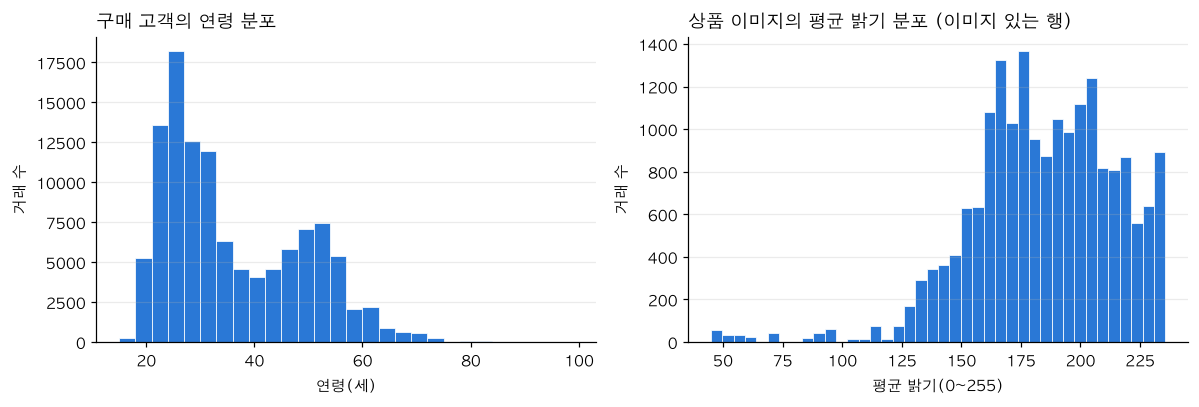

In [13]:
# 6.1 히스토그램: 연령, 이미지 밝기
img_rows = df[df["has_image"]]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(df["age"], bins=np.arange(15, 100, 3), color=BLUE, edgecolor="white", linewidth=0.5)
label(axes[0], "구매 고객의 연령 분포", "연령(세)", "거래 수")
axes[1].hist(img_rows["img_mean"], bins=40, color=BLUE, edgecolor="white", linewidth=0.5)
label(axes[1], "상품 이미지의 평균 밝기 분포 (이미지 있는 행)", "평균 밝기(0~255)", "거래 수")
plt.tight_layout()
plt.show()

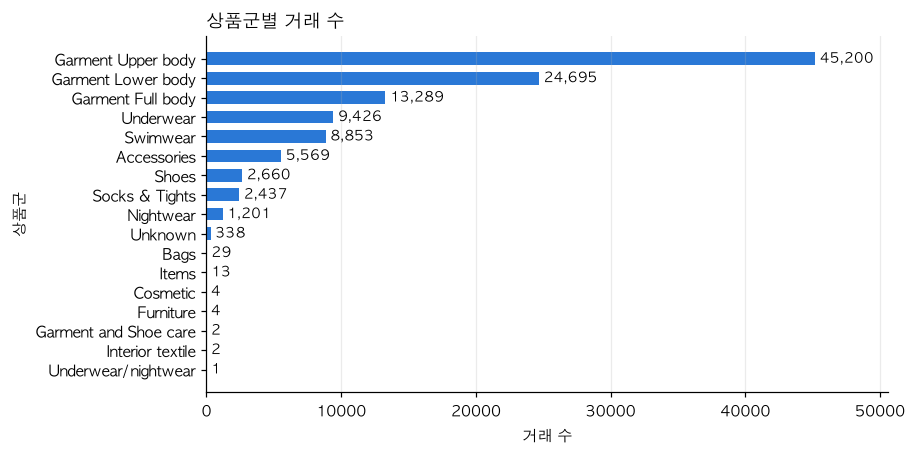

In [14]:
# 6.2 막대그래프: 상품군별 거래 수
counts = df["product_group_name"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.barh(counts.index, counts.values, color=BLUE, height=0.65)
ax.bar_label(bars, labels=[f"{v:,}" for v in counts.values], padding=3, fontsize=9)
ax.set_xlim(0, counts.max() * 1.12)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", alpha=0.25)
label(ax, "상품군별 거래 수", "거래 수", "상품군")
plt.show()

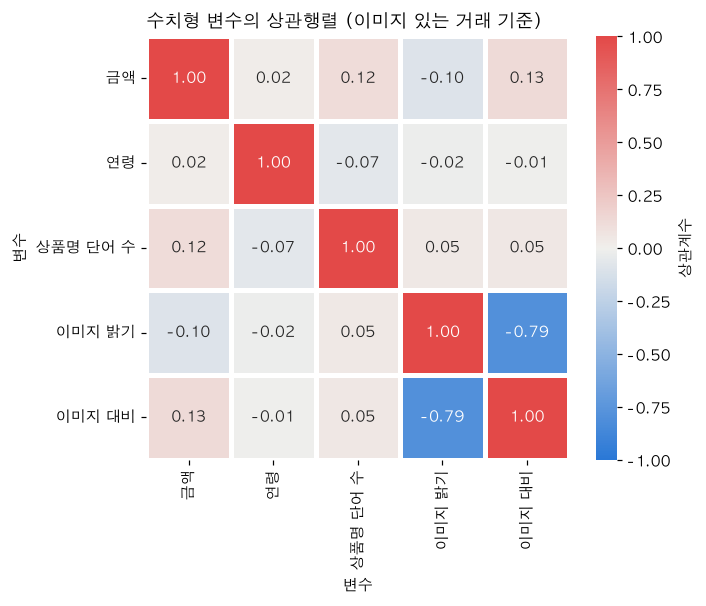

In [15]:
# 6.3 히트맵: 상관행렬 (이미지 변수가 실제로 있는 행 기준)
cols = {"amount": "금액", "age": "연령", "prod_name_word_count": "상품명 단어 수",
        "img_mean": "이미지 밝기", "img_std": "이미지 대비"}
corr_matrix = img_rows[list(cols)].corr().rename(index=cols, columns=cols)

fig, ax = plt.subplots(figsize=(6.2, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap=DIV, vmin=-1, vmax=1, center=0,
            linewidths=2, linecolor="white", cbar_kws={"label": "상관계수"}, ax=ax)
label(ax, "수치형 변수의 상관행렬 (이미지 있는 거래 기준)", "변수", "변수")
ax.grid(False)
plt.show()

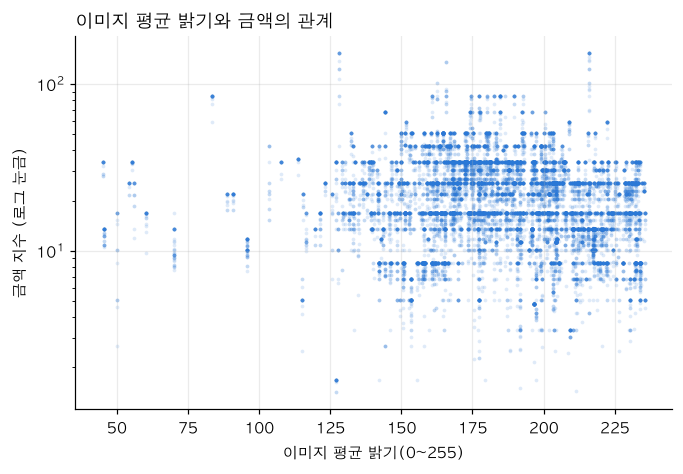

In [16]:
# 6.4 산점도: 이미지 밝기와 금액 (이미지 있는 행)
fig, ax = plt.subplots(figsize=(7, 4.4))
ax.scatter(img_rows["img_mean"], img_rows["amount"], s=6, alpha=0.15, color=BLUE, linewidths=0)
ax.set_yscale("log")
ax.grid(axis="x", alpha=0.25)
label(ax, "이미지 평균 밝기와 금액의 관계", "이미지 평균 밝기(0~255)", "금액 지수 (로그 눈금)")
plt.show()

제외한 달: 2018-09 2020-09


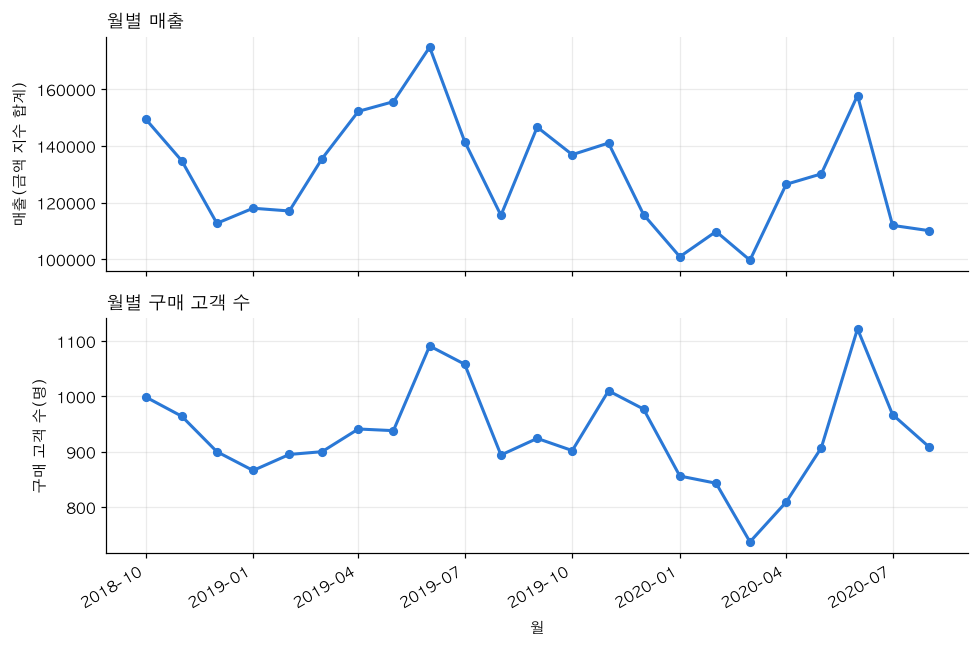

In [17]:
# 6.5 라인차트: 월별 매출과 구매 고객 수 (일부만 포함된 첫 달과 마지막 달 제외)
monthly = df.set_index("t_dat").resample("MS").agg(
    revenue=("amount", "sum"), customers=("customer_id", "nunique")
)
full = monthly.iloc[1:-1]
print("제외한 달:", monthly.index[0].strftime("%Y-%m"), monthly.index[-1].strftime("%Y-%m"))

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(full.index, full["revenue"], color=BLUE, linewidth=2, marker="o", markersize=5)
label(axes[0], "월별 매출", "", "매출(금액 지수 합계)")
axes[1].plot(full.index, full["customers"], color=BLUE, linewidth=2, marker="o", markersize=5)
label(axes[1], "월별 구매 고객 수", "월", "구매 고객 수(명)")
for ax in axes:
    ax.grid(axis="x", alpha=0.25)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

**해석**
- 연령은 중앙값 31세 부근에 몰려 있고 오른쪽으로 길게 퍼집니다. 시사점: 마케팅 메시지는 20~30대 취향에 맞추는 것이 효율적입니다.
- 상품군별 거래 수는 `Garment Upper body`가 45,200건(39.7%)으로 가장 많습니다. 시사점: 상의 중심의 재고와 프로모션이 전체 거래에 미치는 영향이 큽니다.
- 상관행렬과 산점도에서 금액과 이미지 밝기의 관계는 뚜렷하지 않고(r=-0.10), 점들이 넓게 퍼져 있습니다. 시사점: 밝기만으로 가격대를 예측하려는 시도는 효과가 낮습니다. 이 히트맵은 이미지가 있는 거래(18,952행)만으로 계산했기 때문에 5장의 전체 거래 기준 값과 다릅니다. 금액과 상품명 단어 수는 전체에서 -0.03, 이미지가 있는 거래에서 0.12로 부호까지 달라질 만큼 약한 관계이고, 금액과 연령도 0.05와 0.02로 모두 0에 가깝습니다.
- 월별 매출은 2019년 2019-06(174,838), 2020년 2020-06(157,781)에 해당 연도 최고였고, 이 달의 구매 고객 수도 각각 1,091명, 1,122명으로 월 평균 931명보다 많습니다. 시사점: 매출 증가가 객단가가 아니라 **구매 고객 수 증가**에서 나오므로 성수기 전에 고객 접점을 늘리는 전략이 유효합니다.

## 7. RFM 기반 고객 세분화

`DataAnalyzer.calculate_rfm()`이 고객별 지표와 점수, 세그먼트를 계산합니다.

| 지표 | 정의 | 좋은 방향 |
|---|---|---|
| Recency | 기준일 − 마지막 구매일(일). 기준일은 마지막 거래일 다음 날인 **2020-09-23** | 작을수록 |
| Frequency | 구매한 **서로 다른 날짜 수** (같은 날 여러 상품을 사도 1회) | 클수록 |
| Monetary | `amount` 합계 (원본 금액, 클리핑하지 않음) | 클수록 |

각 지표를 1~5점으로 바꾸고(같은 값은 같은 점수), 점수 조합으로 세그먼트를 나눕니다. 위 조건이 먼저 적용됩니다.

| 세그먼트 | 조건 | 의미 |
|---|---|---|
| VIP | R≥4, F≥4, M≥4 | 최근에 자주, 많이 구매 |
| Loyal | R≥3, F≥3 | 꾸준히 구매하는 단골 |
| New | R≥4, F≤2 | 최근에 처음 또는 가끔 구매 |
| At Risk | R≤2, F≥3 | 예전엔 자주 샀지만 최근 구매 없음 |
| Churned | R≤2 (위에서 걸리지 않은 고객) | 오래전 마지막 구매, 이탈 |
| Regular | 그 외 | 일반 고객 |

In [18]:
rfm = analyzer.calculate_rfm(customer_col="customer_id", date_col="t_dat", amount_col="amount")
display(rfm.head())

summary = analyzer.segment_summary()
summary.rename(
    columns={
        "customers": "고객 수", "avg_recency": "평균 Recency(일)", "avg_frequency": "평균 Frequency(회)",
        "avg_monetary": "평균 Monetary", "total_monetary": "총 Monetary",
        "customer_pct": "고객 비중(%)", "revenue_pct": "매출 비중(%)",
    }
).round(1)

,recency,frequency,monetary,R,F,M,segment
customer_id,,,,,,,
000f72a562e6a77624d7f6330b9bbaef1ecdfef26a9c14869b48607320c428ca,10,2,577.728814,5,2,4,New
0012cb3404b7e0a54c6b88b20b35aa8944c264fa9975acdd40cb9c839266102d,340,6,556.576271,2,4,4,At Risk
0014669814e09bf5ab74d7d4d6befa94f303ff2a04b9f61bd15690eece7ad0cf,72,1,13.542373,4,1,1,New
001e7e640da3c0a2ae3c1444d9fba300646d050e7ba6012d07aa5dde549e6943,85,8,1114.288136,4,4,5,VIP
0053ed9ca8aec99187532961a73a12e26a671930890fd1ece01539d89a492fbc,50,7,595.915254,4,4,4,VIP


,고객 수,평균 Recency(일),평균 Frequency(회),평균 Monetary,총 Monetary,고객 비중(%),매출 비중(%)
segment,,,,,,,
VIP,1190,36.6,17.6,1696.7,2019060.8,24.0,64.1
Loyal,956,105.9,6.3,593.7,567614.7,19.3,18.0
At Risk,520,373.6,5.6,530.5,275862.2,10.5,8.8
Regular,448,158.0,1.4,139.0,62279.4,9.0,2.0
New,386,48.7,1.4,127.3,49137.6,7.8,1.6
Churned,1462,499.3,1.2,119.7,174928.7,29.5,5.6


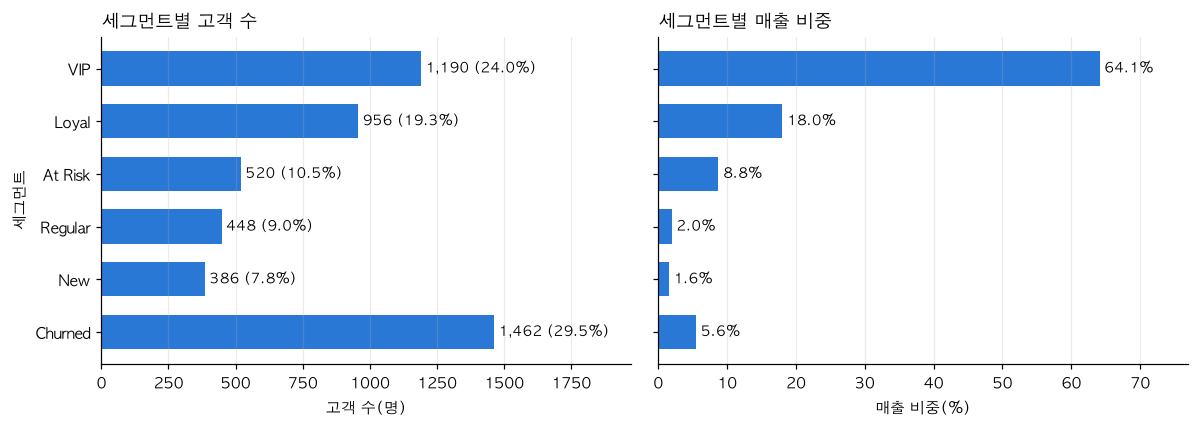

In [19]:
order = summary.index.tolist()  # 평균 Monetary 높은 순

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
b1 = axes[0].barh(order, summary["customers"], color=BLUE, height=0.65)
axes[0].bar_label(b1, labels=[f"{v:,} ({p:.1f}%)" for v, p in zip(summary["customers"], summary["customer_pct"])],
                  padding=3, fontsize=9)
axes[0].set_xlim(0, summary["customers"].max() * 1.35)
label(axes[0], "세그먼트별 고객 수", "고객 수(명)", "세그먼트")
b2 = axes[1].barh(order, summary["revenue_pct"], color=BLUE, height=0.65)
axes[1].bar_label(b2, labels=[f"{v:.1f}%" for v in summary["revenue_pct"]], padding=3, fontsize=9)
axes[1].set_xlim(0, summary["revenue_pct"].max() * 1.2)
label(axes[1], "세그먼트별 매출 비중", "매출 비중(%)", "")
axes[0].invert_yaxis()  # y축을 공유하므로 한 번만 뒤집는다
for ax in axes:
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

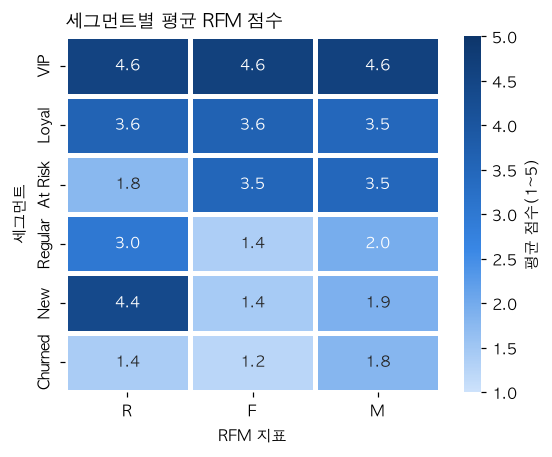

In [20]:
scores = rfm.groupby("segment")[["R", "F", "M"]].mean().loc[order]

fig, ax = plt.subplots(figsize=(5.5, 4.2))
sns.heatmap(scores, annot=True, fmt=".1f", cmap=SEQ, vmin=1, vmax=5, linewidths=2, linecolor="white",
            cbar_kws={"label": "평균 점수(1~5)"}, ax=ax)
label(ax, "세그먼트별 평균 RFM 점수", "RFM 지표", "세그먼트")
ax.grid(False)
plt.show()

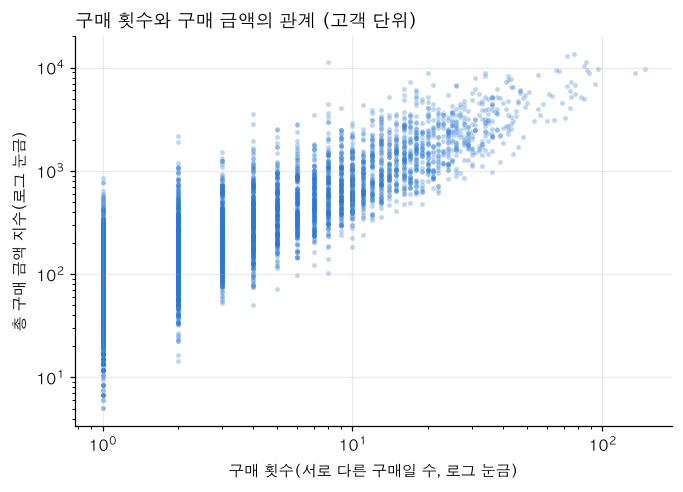

,x,y,n,r
0,frequency,monetary,4962,0.827
1,recency,frequency,4962,-0.408


In [21]:
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.scatter(rfm["frequency"], rfm["monetary"], s=10, alpha=0.3, color=BLUE, linewidths=0)
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(axis="x", alpha=0.25)
label(ax, "구매 횟수와 구매 금액의 관계 (고객 단위)", "구매 횟수(서로 다른 구매일 수, 로그 눈금)", "총 구매 금액 지수(로그 눈금)")
plt.show()

analyzer.correlation_pairs([("frequency", "monetary"), ("recency", "frequency")], data=rfm).round(3)

**해석**
- **VIP**는 고객 1,190명(24.0%)이 매출의 64.1%를 만듭니다. 평균 17.6회 구매하고 마지막 구매는 평균 37일 전입니다. 시사점: 매출이 VIP에 크게 의존하므로 이들의 이탈 관리가 가장 중요합니다.
- **Loyal**(956명, 매출 18.0%)은 평균 6.3회, 마지막 구매 평균 106일 전으로 안정적인 단골입니다. 시사점: VIP로 올릴 수 있는 후보군입니다.
- **At Risk**(520명)는 평균 5.6회 구매했지만 마지막 구매가 평균 374일 전입니다. **Churned**(1,462명, 29.5%)는 평균 1.2회 구매했고 평균 구매 금액이 119.7으로, At Risk(530.5)의 23% 수준입니다. 시사점: 복귀 캠페인은 과거 가치가 큰 At Risk부터 시작해야 합니다.
- **New**(386명)와 **Regular**(448명)는 평균 구매 횟수가 각각 1.4회, 1.4회로 재구매 전이라 기여도가 낮습니다 (매출 1.6%, 2.0%).
- 구매 횟수와 총 구매 금액의 상관계수는 **0.83**, 구매 횟수와 Recency는 -0.41입니다. 시사점: 고객 가치는 한 번에 많이 사는 것보다 **자주 사는 것**에서 나오므로 재구매 유도가 핵심이고, F와 M 점수는 정보가 많이 겹칩니다.

## 8. 비즈니스 인사이트

각 인사이트는 근거, 실행, 검증 순서로 정리했습니다. `README.md`에도 같은 내용이 있습니다.

### 인사이트 1. 소수의 VIP가 매출 대부분을 만든다
- **(근거)** VIP는 고객 1,190명(24.0%)인데 매출의 64.1%를 차지한다. 평균 구매 17.6회, 마지막 구매는 평균 37일 전이다. 고객 전체로 봐도 상위 10%가 매출의 50.2%를 만든다 (7장 RFM 표, 막대그래프).
- **(실행)** VIP 대상 → 신상품 사전 공개와 전용 혜택 등 멤버십 혜택 강화 → 이탈 방지. VIP 1명의 평균 구매 금액이 New 고객의 13배이므로 혜택 비용을 감안해도 우선순위가 높다.
- **(검증)** 혜택의 비용 대비 효과를 계산하려면 마진과 쿠폰 사용 데이터가 필요하다. 또한 VIP 매출이 소수의 고가 구매에 몰린 것이라면 반증이 되므로, 구매 단가 분포를 함께 확인해야 한다.

### 인사이트 2. 과거 가치가 큰 At Risk를 Churned보다 먼저 공략한다
- **(근거)** At Risk는 고객 520명(10.5%)으로, 평균 5.6회 구매했고 평균 구매 금액이 530.5이지만 마지막 구매가 평균 374일 전이다. Churned(고객 1,462명, 29.5%)는 평균 1.2회, 119.7으로, At Risk의 과거 구매 가치가 4.4배 높다.
- **(실행)** At Risk 대상 → 과거 구매 카테고리 기반의 개인화 추천 메일과 복귀 쿠폰 발송 → 소수 인원으로 큰 매출 회복을 기대할 수 있다. 쿠폰 비용이 한정돼 있다면 Churned보다 At Risk에 먼저 배정한다.
- **(검증)** 관측 기간이 2년이라 '오래 구매 안 함'이 곧 이탈은 아닐 수 있고(반증 가능성), 이탈 사유(가격, 품질, 경쟁사)를 알려면 설문 또는 방문 로그 데이터가 추가로 필요하다.

### 인사이트 3. 첫 구매 이후 재구매로 이어지지 못한 고객이 많다
- **(근거)** 전체 고객의 32.7%(1,622명)가 한 번만 구매했고, 이 중 69.1%가 Churned다. Churned의 평균 구매 횟수는 1.2회로, 이탈 고객 대부분이 1~2회 구매에서 끝났다. 반면 구매 횟수와 총 구매 금액의 상관계수는 0.83(강한 양의 관계)이며, 구매 횟수가 총 구매 금액 차이의 약 68%를 설명한다.
- **(실행)** New·Regular 대상 → 첫 구매 후 일정 기간 안에 2차 구매를 유도하는 웰컴 메시지와 2회차 구매 쿠폰 → 재구매율 상승과 장기적으로 VIP·Loyal 비중 확대를 기대한다.
- **(검증)** 첫 구매 후 2차 구매까지의 간격 분포와 가입 월별 재구매율(코호트 분석)이 추가로 필요하다. 한 번만 산 고객이 선물 구매처럼 원래 재구매 의사가 없는 경우라면 반증이 된다.

### 인사이트 4. 6월 성수기에 맞춘 시즌 캠페인
- **(근거)** 월 매출이 2019년(2019-06, 174,838)과 2020년(2020-06, 157,781) 모두 6월에 해당 연도 최고였고, 월 평균 130,188을 크게 웃돈다. 6월의 구매 고객 수도 1,091명, 1,122명으로 월 평균 931명보다 많다 (6장 라인차트, 일부만 포함된 첫 달과 마지막 달은 제외).
- **(실행)** 활동 중인 Loyal·VIP 대상 → 5월 말부터 시즌 상품 사전 안내와 한정 혜택 → 성수기 매출 상승폭 확대. 재고와 프로모션도 6월에 맞춰 선행 준비한다.
- **(검증)** 관측 기간이 2년뿐이어서 계절성이라 단정하기 어렵다(반증 가능성). 상품군별 월별 매출과 프로모션 일정 데이터가 있으면 원인을 가를 수 있다.

## 9. 한계와 후속 과제

- **이미지 커버리지**: 이미지가 있는 거래는 16.7%뿐이고, 이미지 피처 결측 83.3%를 그룹 평균으로 대치했습니다. 이미지 분석 결과는 판매량 상위 상품(765개)에만 적용되며 전체로 일반화하기 어렵습니다.
- **관측 기간**: 약 2년(2018-09-20 ~ 2020-09-22)입니다. Churned는 "관측 기간 안에 오래 구매하지 않음"이라는 뜻이어서 실제 이탈과 다를 수 있습니다. 기간의 처음과 끝 달(2018-09, 2020-09)은 일부만 포함돼 월별 추이에서 제외했습니다.
- **금액**: 정규화된 상대 금액이라 절대 금액이나 마진을 해석할 수 없습니다.
- **세그먼트 정의**: 점수 조건은 사람이 정한 규칙이며, 다른 기준을 쓰면 세그먼트 크기가 달라집니다.
- **보너스 과제**(이미지 고급 피처, 코호트 분석, Plotly)는 수행하지 않았습니다. 코호트 분석은 인사이트 3의 검증 항목이기도 해서 다음 단계로 적합합니다.